<a href="https://colab.research.google.com/github/Ehsan-Roohi/DSMC_Python/blob/main/Collision_Frequency_MB_3_Schemes_with_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


Choose method: [1] SBT, [2] DCP, [3] NTC: 3
--- DSMC Relaxation using method: NTC ---
Initializing particles with Maxwell-Boltzmann velocity distribution...
Initialized 500 particles.
Step: 4000/40000 | Total Collisions: 466
Step: 8000/40000 | Total Collisions: 1721
Step: 12000/40000 | Total Collisions: 3605
Step: 16000/40000 | Total Collisions: 5929
Step: 20000/40000 | Total Collisions: 8615
Step: 24000/40000 | Total Collisions: 11568
Step: 28000/40000 | Total Collisions: 14776
Step: 32000/40000 | Total Collisions: 18239
Step: 36000/40000 | Total Collisions: 21816
Step: 40000/40000 | Total Collisions: 25603

Simulation finished in 108.05 seconds.
Final Equilibrium Temperature: 282.18 K
Total Simulated Collisions: 25603
Total Theoretical Collisions (TCOL): 40084.18
FINAL RATIO (Simulated/Theoretical): 0.6387


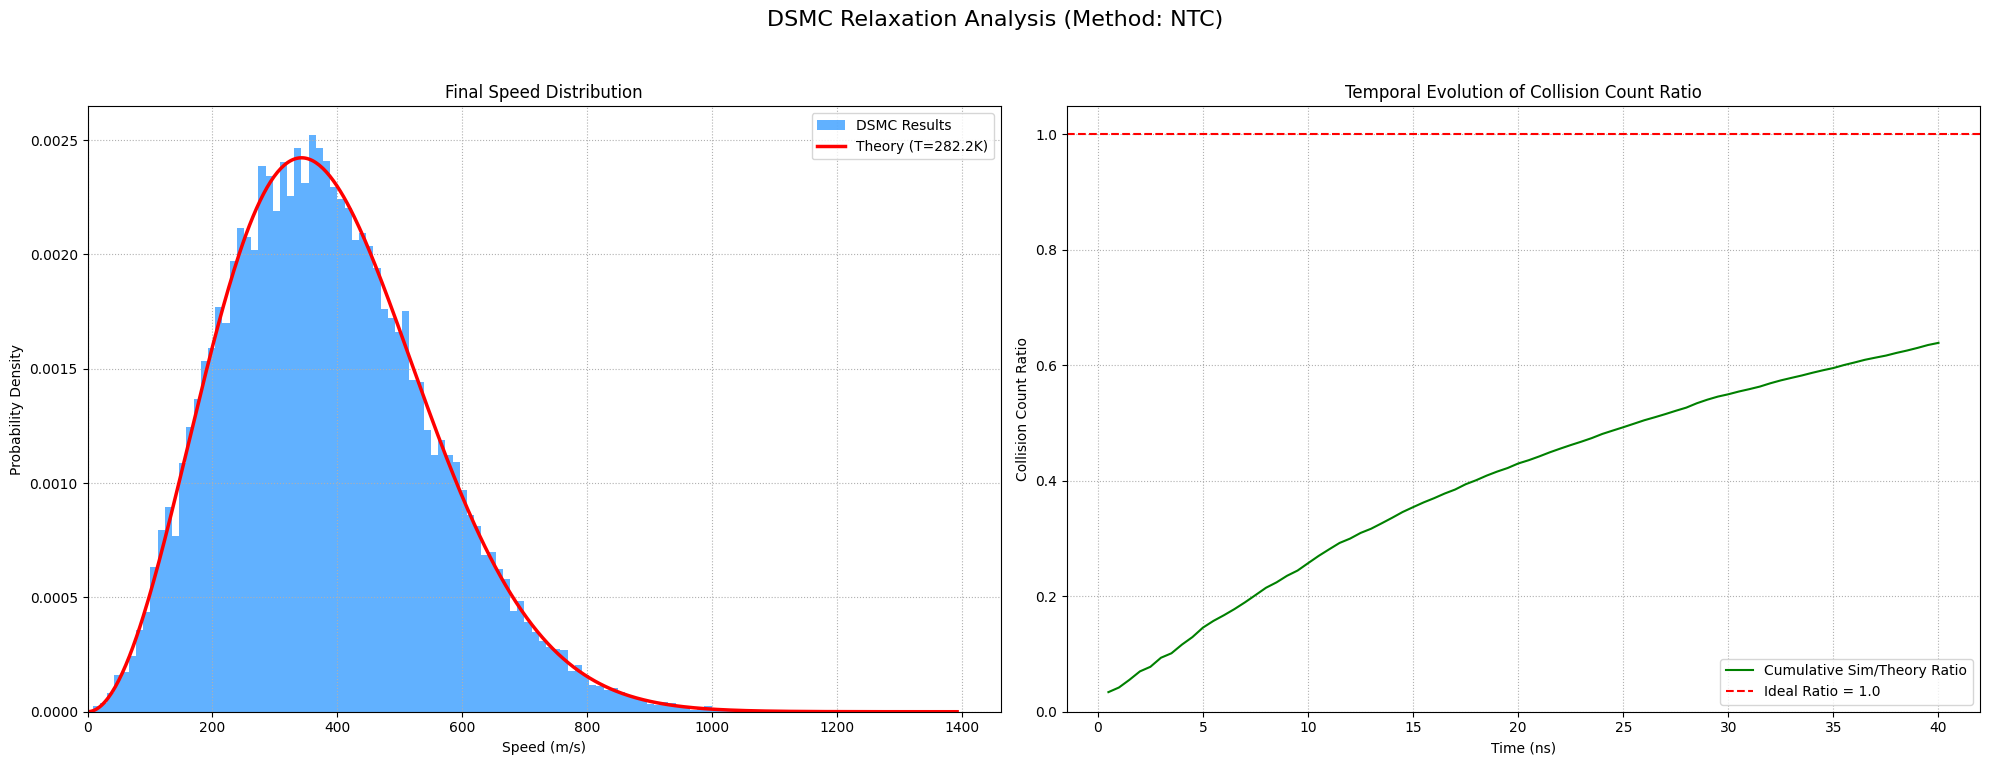

In [1]:
# -*- coding: utf-8 -*-
# --- DSMC Relaxation - V4.7 - FINAL CORRECTED AND COMPLETE CODE ---
# This version provides a complete, runnable script with a choice between three
# collision schemes and fixes the NameError by defining functions in the correct order.

import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit
import time

# --- Constants and Physical Parameters ---
MASS_AR = 39.948e-3 / 6.022e23
KB = 1.380649e-23
D_REF_AR = 4.17e-10
T_REF_AR = 273.0
OMEGA_VHS = 0.50
PI = 3.141592654

# --- Simulation Parameters ---
LX = 1.0e-6
RHO_INIT = 1.78
T_INIT = 273.0
NUM_CELLS_X = 100
PARTICLES_PER_CELL_INIT = 5
TOTAL_PARTICLES_SIM = NUM_CELLS_X * PARTICLES_PER_CELL_INIT
N_DENSITY_REAL = RHO_INIT / MASS_AR
# This conceptual volume is used to correctly calculate FNUM
CELL_VOLUME_CONCEPTUAL = (LX) / NUM_CELLS_X
FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
DT = 1.0e-12
TOTAL_TIME = 4.0e-8
SAMPLING_START_TIME = 1.0e-8
SAMPLING_INTERVAL = 500

# --- Numba-Jitted Core Functions ---

@njit(nopython=True)
def gamma_function_approx(x):
    a = 1.0
    y = x
    if y < 1.0: a = a / y
    else:
        while y >= 1.0:
            y = y - 1.0
            a = a * (y + 1.0)
    gamma_val = a * (1.0 - 0.5748646*y + 0.9512363*y**2 - 0.6998588*y**3 + 0.4245549*y**4 - 0.1010678*y**5)
    return gamma_val

@njit(nopython=True)
def calculate_vhs_sigma_g(vr_mag):
    if vr_mag < 1e-9: return 0.0
    exponent = OMEGA_VHS - 0.5
    c_ref_sq = 2 * KB * T_REF_AR / MASS_AR
    gamma_val = gamma_function_approx(2.5 - OMEGA_VHS)
    sigma_g = (PI * D_REF_AR**2) * vr_mag * ((c_ref_sq / vr_mag**2)**exponent) / gamma_val
    return sigma_g

@njit(nopython=True)
def perform_post_collision(p1_idx, p2_idx, particles, rng_state):
    vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
    vr_mag = np.sqrt(np.sum(vr**2))
    if vr_mag < 1e-9: return False
    vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
    cos_chi = 2 * rng_state.random() - 1.0
    sin_chi = np.sqrt(1.0 - cos_chi**2)
    phi_chi = 2.0 * PI * rng_state.random()
    rand_vec = np.array([sin_chi * np.cos(phi_chi), sin_chi * np.sin(phi_chi), cos_chi])
    vr_prime = vr_mag * rand_vec
    particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
    particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime
    return True

@njit(nopython=True)
def perform_collisions(method, particles, indices_in_cell, cell_vol, dt, fnum, rng_state, sigma_g_max_cell):
    n_accepted = 0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2: return 0, sigma_g_max_cell

    if method == 1: # SBT
        prob_const = fnum * dt / cell_vol
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
                vr_mag = np.sqrt(np.sum(vr**2))
                if vr_mag < 1e-9: continue
                sigma_g = calculate_vhs_sigma_g(vr_mag)
                collision_prob = prob_const * sigma_g
                if rng_state.random() < collision_prob:
                    if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                        n_accepted += 1
        return n_accepted, sigma_g_max_cell
    elif method == 2: # DCP
        num_pairs = num_particles_in_cell * (num_particles_in_cell - 1) // 2
        pairs = np.empty((num_pairs, 2), dtype=np.int32)
        weights = np.empty(num_pairs, dtype=np.float64)
        pair_count = 0
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                distance = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                weights[pair_count] = 1.0 / (distance + 1e-10)
                pairs[pair_count, 0] = p1_idx
                pairs[pair_count, 1] = p2_idx
                pair_count += 1
        sum_of_sigma_g = 0.0
        for i in range(num_pairs):
            p1_idx, p2_idx = pairs[i]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sum_of_sigma_g += calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
        expected_collisions = (sum_of_sigma_g * fnum * dt) / cell_vol
        num_collisions_to_perform = int(np.floor(expected_collisions + rng_state.random()))
        for _ in range(num_collisions_to_perform):
            if np.sum(weights) < 1e-12: break
            selected_idx = np.argmax(weights)
            p1_idx, p2_idx = pairs[selected_idx]
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
            weights[selected_idx] = 0.0
        return n_accepted, sigma_g_max_cell
    elif method == 3: # NTC
        num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
        if sigma_g_max_cell < 1e-20: sigma_g_max_cell = 1e-18
        num_pairs_to_select = int(num_pairs_float * fnum * sigma_g_max_cell * dt / cell_vol + rng_state.random())
        for _ in range(num_pairs_to_select):
            p1_idx_local = rng_state.integers(0, num_particles_in_cell)
            p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            while p1_idx_local == p2_idx_local: p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            p1_idx, p2_idx = indices_in_cell[p1_idx_local], indices_in_cell[p2_idx_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
            if sigma_g_current > sigma_g_max_cell: sigma_g_max_cell = sigma_g_current
            if sigma_g_max_cell > 1e-20 and rng_state.random() < sigma_g_current / sigma_g_max_cell:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
        return n_accepted, sigma_g_max_cell
    return 0, sigma_g_max_cell

@njit(nopython=True)
def calculate_total_theoretical_collisions(TOTAL_TIME, avg_temp, total_volume):
    spm1 = PI * D_REF_AR**2
    temp_factor = (avg_temp / T_REF_AR)**(1.0 - OMEGA_VHS)
    velocity_factor = np.sqrt(KB * T_REF_AR / (PI * MASS_AR))
    tcol = (1.0 * TOTAL_TIME * N_DENSITY_REAL**2 * total_volume * spm1 * temp_factor * velocity_factor) / FNUM
    return tcol

# --- Plotting and Initialization functions defined BEFORE run_dsmc_simulation ---

def plot_results(sampled_speeds, final_temp, method_name, time_history, ratio_history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f'DSMC Relaxation Analysis (Method: {method_name})', fontsize=16)

    ax1.hist(sampled_speeds, bins=100, density=True, label=f'DSMC Results', alpha=0.7, color='dodgerblue')
    if len(sampled_speeds) > 0: v_max_range = np.max(sampled_speeds) * 1.2
    else: v_max_range = 1500
    v_theory = np.linspace(0, v_max_range, 500)
    pv_theory = ((MASS_AR / (2 * PI * KB * final_temp))**1.5 * 4 * PI * v_theory**2 * np.exp(-MASS_AR * v_theory**2 / (2 * KB * final_temp)))
    ax1.plot(v_theory, pv_theory, 'r-', linewidth=2.5, label=f'Theory (T={final_temp:.1f}K)')
    ax1.set_xlabel('Speed (m/s)'); ax1.set_ylabel('Probability Density'); ax1.set_title('Final Speed Distribution')
    ax1.legend(); ax1.grid(True, linestyle=':'); ax1.set_xlim(left=0)

    ax2.plot(np.array(time_history) * 1e9, ratio_history, 'g-', label='Cumulative Sim/Theory Ratio')
    ax2.axhline(1.0, color='r', linestyle='--', label='Ideal Ratio = 1.0')
    ax2.set_xlabel('Time (ns)'); ax2.set_ylabel('Collision Count Ratio'); ax2.set_title('Temporal Evolution of Collision Count Ratio')
    ax2.legend(); ax2.grid(True, linestyle=':'); ax2.set_ylim(bottom=0)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

def initialize_particles(rng_state):
    particles = np.zeros((TOTAL_PARTICLES_SIM, 4))
    print("Initializing particles with Maxwell-Boltzmann velocity distribution...")
    particles[:, 0] = rng_state.random(TOTAL_PARTICLES_SIM) * LX

    v_thermal_std = np.sqrt(KB * T_INIT / MASS_AR)
    particles[:, 1:4] = rng_state.normal(0, v_thermal_std, (TOTAL_PARTICLES_SIM, 3))
    particles[:, 1:4] -= np.mean(particles[:, 1:4], axis=0)

    print(f"Initialized {TOTAL_PARTICLES_SIM} particles.")
    return particles

def run_dsmc_simulation(method_code):
    method_map = {1: 'SBT', 2: 'DCP', 3: 'NTC'}
    collision_method_name = method_map[method_code]
    print(f"--- DSMC Relaxation using method: {collision_method_name} ---")

    rng_state = np.random.default_rng(seed=42)
    particles = initialize_particles(rng_state)

    sampled_speeds = []
    time_history, ratio_history = [], []
    sigma_g_max = np.full(NUM_CELLS_X, 1e-18)

    total_simulated_collisions = 0

    start_time = time.time()
    num_steps = int(TOTAL_TIME / DT)
    sampling_start_step = int(SAMPLING_START_TIME / DT)
    cell_width = LX / NUM_CELLS_X

    # <<< CORRECTED: Total volume definition to be consistent >>>
    total_volume = LX

    for step in range(1, num_steps + 1):
        particles[:, 0] += particles[:, 1] * DT
        particles[:, 0] %= LX
        cell_indices = (particles[:, 0] / cell_width).astype(np.int64)

        accepted_this_step = 0
        for i in range(NUM_CELLS_X):
            indices_in_cell_i = np.where(cell_indices == i)[0]
            n_accepted, new_sigma_g_max = perform_collisions(method_code, particles, indices_in_cell_i, CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state, sigma_g_max[i])
            sigma_g_max[i] = new_sigma_g_max
            accepted_this_step += n_accepted

        total_simulated_collisions += accepted_this_step

        if step % SAMPLING_INTERVAL == 0 and step > 1:
            current_time = step * DT
            current_temp = (1.0 / (3.0 * KB)) * MASS_AR * np.mean(np.var(particles[:, 1:4], axis=0)) * 3.0

            if current_temp > 10.0:
                total_theoretical_collisions = calculate_total_theoretical_collisions(current_time, current_temp, total_volume)
                if total_theoretical_collisions > 0:
                    ratio = total_simulated_collisions / total_theoretical_collisions
                    time_history.append(current_time)
                    ratio_history.append(ratio)

        if step >= sampling_start_step and step % 200 == 0:
            sampled_speeds.extend(np.sqrt(np.sum(particles[:, 1:4]**2, axis=1)))

        if step % (num_steps // 10) == 0:
            print(f"Step: {step}/{num_steps} | Total Collisions: {total_simulated_collisions}")

    end_time = time.time()
    final_temp = (1.0 / (3.0 * KB)) * MASS_AR * np.mean(np.sum(np.var(particles[:, 1:4], axis=0)))
    print(f"\nSimulation finished in {end_time - start_time:.2f} seconds.")
    print(f"Final Equilibrium Temperature: {final_temp:.2f} K")
    print(f"Total Simulated Collisions: {total_simulated_collisions}")

    total_theoretical_collisions_final = calculate_total_theoretical_collisions(TOTAL_TIME, final_temp, total_volume)
    print(f"Total Theoretical Collisions (TCOL): {total_theoretical_collisions_final:.2f}")

    if total_theoretical_collisions_final > 0:
        final_ratio = total_simulated_collisions / total_theoretical_collisions_final
        print(f"FINAL RATIO (Simulated/Theoretical): {final_ratio:.4f}")

    if sampled_speeds:
        plot_results(np.array(sampled_speeds), final_temp, collision_method_name, time_history, ratio_history)

if __name__ == "__main__":
    while True:
        choice = input("Choose method: [1] SBT, [2] DCP, [3] NTC: ")
        if choice in ['1', '2', '3']:
            run_dsmc_simulation(method_code=int(choice))
            break
        else:
            print("Invalid input.")

/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


Choose method: [1] SBT, [2] DCP, [3] NTC: 1
--- DSMC Relaxation using method: SBT ---
Initializing particles with Maxwell-Boltzmann velocity distribution...
Initialized 500 particles.
Step: 4000/40000 | Total Collisions: 4032
Step: 8000/40000 | Total Collisions: 8011
Step: 12000/40000 | Total Collisions: 12079
Step: 16000/40000 | Total Collisions: 16030
Step: 20000/40000 | Total Collisions: 19952
Step: 24000/40000 | Total Collisions: 24028
Step: 28000/40000 | Total Collisions: 28056
Step: 32000/40000 | Total Collisions: 31984
Step: 36000/40000 | Total Collisions: 36021
Step: 40000/40000 | Total Collisions: 40011

Simulation finished in 109.32 seconds.
Final Equilibrium Temperature: 282.18 K
Total Simulated Collisions: 40011
Total Theoretical Collisions (TCOL): 40084.18
FINAL RATIO (Simulated/Theoretical): 0.9982


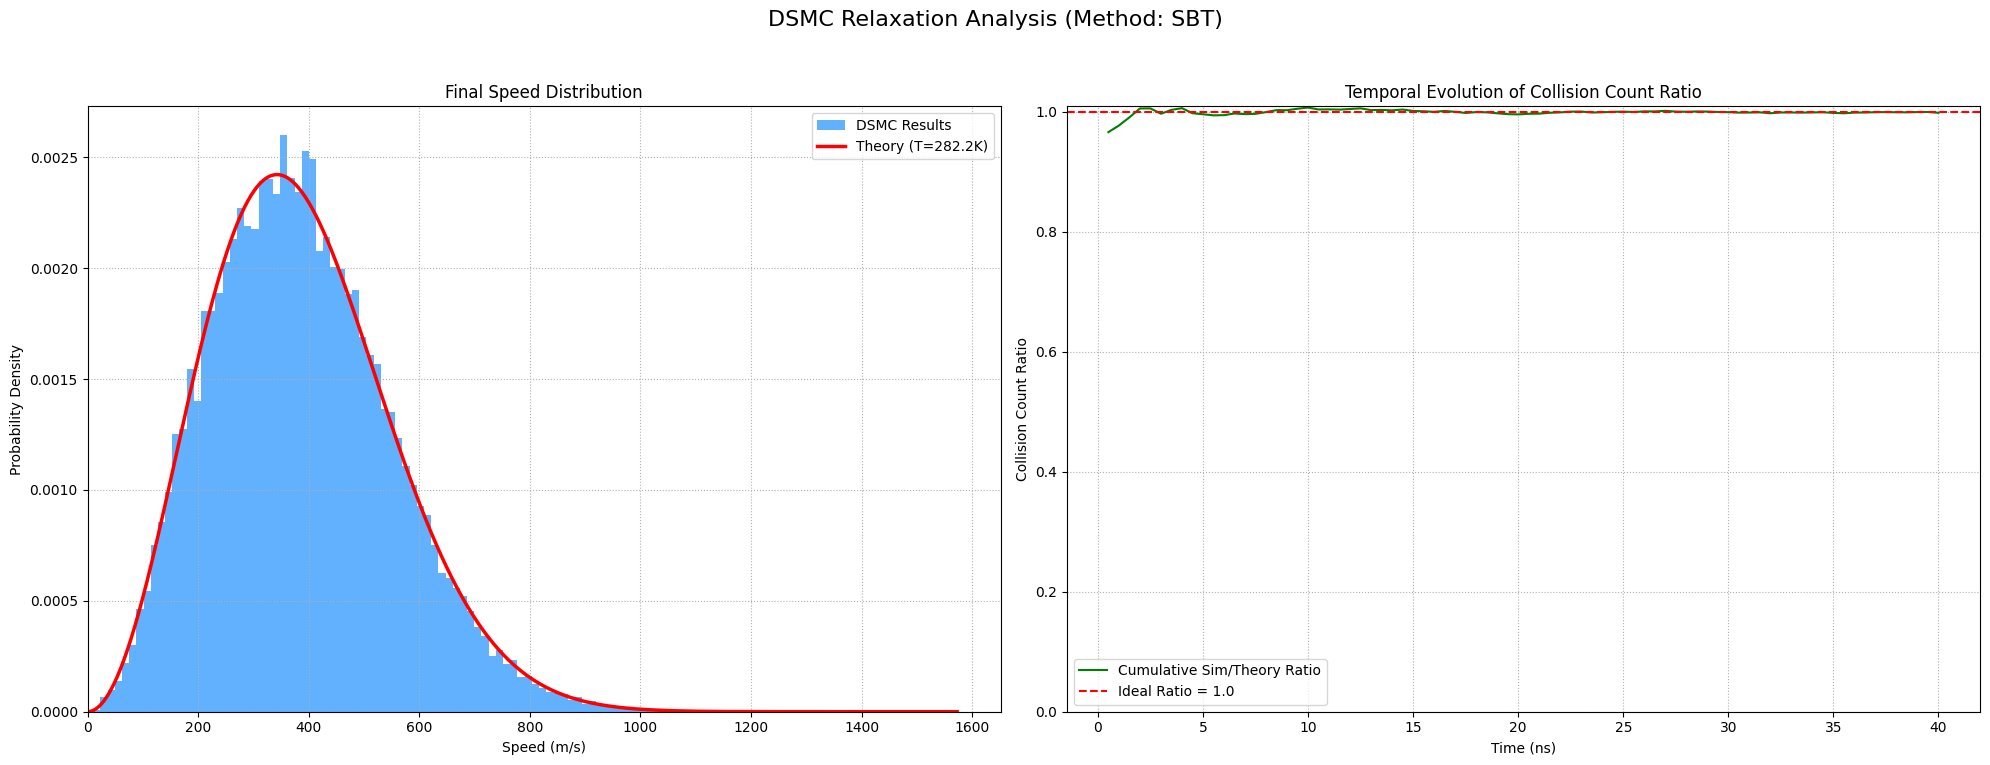

In [2]:
# -*- coding: utf-8 -*-
# --- DSMC Relaxation - V4.7 - FINAL CORRECTED AND COMPLETE CODE ---
# This version provides a complete, runnable script with a choice between three
# collision schemes and fixes the NameError by defining functions in the correct order.

import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit
import time

# --- Constants and Physical Parameters ---
MASS_AR = 39.948e-3 / 6.022e23
KB = 1.380649e-23
D_REF_AR = 4.17e-10
T_REF_AR = 273.0
OMEGA_VHS = 0.50
PI = 3.141592654

# --- Simulation Parameters ---
LX = 1.0e-6
RHO_INIT = 1.78
T_INIT = 273.0
NUM_CELLS_X = 100
PARTICLES_PER_CELL_INIT = 5
TOTAL_PARTICLES_SIM = NUM_CELLS_X * PARTICLES_PER_CELL_INIT
N_DENSITY_REAL = RHO_INIT / MASS_AR
# This conceptual volume is used to correctly calculate FNUM
CELL_VOLUME_CONCEPTUAL = (LX) / NUM_CELLS_X
FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
DT = 1.0e-12
TOTAL_TIME = 4.0e-8
SAMPLING_START_TIME = 1.0e-8
SAMPLING_INTERVAL = 500

# --- Numba-Jitted Core Functions ---

@njit(nopython=True)
def gamma_function_approx(x):
    a = 1.0
    y = x
    if y < 1.0: a = a / y
    else:
        while y >= 1.0:
            y = y - 1.0
            a = a * (y + 1.0)
    gamma_val = a * (1.0 - 0.5748646*y + 0.9512363*y**2 - 0.6998588*y**3 + 0.4245549*y**4 - 0.1010678*y**5)
    return gamma_val

@njit(nopython=True)
def calculate_vhs_sigma_g(vr_mag):
    if vr_mag < 1e-9: return 0.0
    exponent = OMEGA_VHS - 0.5
    c_ref_sq = 2 * KB * T_REF_AR / MASS_AR
    gamma_val = gamma_function_approx(2.5 - OMEGA_VHS)
    sigma_g = (PI * D_REF_AR**2) * vr_mag * ((c_ref_sq / vr_mag**2)**exponent) / gamma_val
    return sigma_g

@njit(nopython=True)
def perform_post_collision(p1_idx, p2_idx, particles, rng_state):
    vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
    vr_mag = np.sqrt(np.sum(vr**2))
    if vr_mag < 1e-9: return False
    vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
    cos_chi = 2 * rng_state.random() - 1.0
    sin_chi = np.sqrt(1.0 - cos_chi**2)
    phi_chi = 2.0 * PI * rng_state.random()
    rand_vec = np.array([sin_chi * np.cos(phi_chi), sin_chi * np.sin(phi_chi), cos_chi])
    vr_prime = vr_mag * rand_vec
    particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
    particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime
    return True

@njit(nopython=True)
def perform_collisions(method, particles, indices_in_cell, cell_vol, dt, fnum, rng_state, sigma_g_max_cell):
    n_accepted = 0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2: return 0, sigma_g_max_cell

    if method == 1: # SBT
        prob_const = fnum * dt / cell_vol
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
                vr_mag = np.sqrt(np.sum(vr**2))
                if vr_mag < 1e-9: continue
                sigma_g = calculate_vhs_sigma_g(vr_mag)
                collision_prob = prob_const * sigma_g
                if rng_state.random() < collision_prob:
                    if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                        n_accepted += 1
        return n_accepted, sigma_g_max_cell
    elif method == 2: # DCP
        num_pairs = num_particles_in_cell * (num_particles_in_cell - 1) // 2
        pairs = np.empty((num_pairs, 2), dtype=np.int32)
        weights = np.empty(num_pairs, dtype=np.float64)
        pair_count = 0
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                distance = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                weights[pair_count] = 1.0 / (distance + 1e-10)
                pairs[pair_count, 0] = p1_idx
                pairs[pair_count, 1] = p2_idx
                pair_count += 1
        sum_of_sigma_g = 0.0
        for i in range(num_pairs):
            p1_idx, p2_idx = pairs[i]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sum_of_sigma_g += calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
        expected_collisions = (sum_of_sigma_g * fnum * dt) / cell_vol
        num_collisions_to_perform = int(np.floor(expected_collisions + rng_state.random()))
        for _ in range(num_collisions_to_perform):
            if np.sum(weights) < 1e-12: break
            selected_idx = np.argmax(weights)
            p1_idx, p2_idx = pairs[selected_idx]
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
            weights[selected_idx] = 0.0
        return n_accepted, sigma_g_max_cell
    elif method == 3: # NTC
        num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
        if sigma_g_max_cell < 1e-20: sigma_g_max_cell = 1e-18
        num_pairs_to_select = int(num_pairs_float * fnum * sigma_g_max_cell * dt / cell_vol + rng_state.random())
        for _ in range(num_pairs_to_select):
            p1_idx_local = rng_state.integers(0, num_particles_in_cell)
            p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            while p1_idx_local == p2_idx_local: p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            p1_idx, p2_idx = indices_in_cell[p1_idx_local], indices_in_cell[p2_idx_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
            if sigma_g_current > sigma_g_max_cell: sigma_g_max_cell = sigma_g_current
            if sigma_g_max_cell > 1e-20 and rng_state.random() < sigma_g_current / sigma_g_max_cell:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
        return n_accepted, sigma_g_max_cell
    return 0, sigma_g_max_cell

@njit(nopython=True)
def calculate_total_theoretical_collisions(TOTAL_TIME, avg_temp, total_volume):
    spm1 = PI * D_REF_AR**2
    temp_factor = (avg_temp / T_REF_AR)**(1.0 - OMEGA_VHS)
    velocity_factor = np.sqrt(KB * T_REF_AR / (PI * MASS_AR))
    tcol = (1.0 * TOTAL_TIME * N_DENSITY_REAL**2 * total_volume * spm1 * temp_factor * velocity_factor) / FNUM
    return tcol

# --- Plotting and Initialization functions defined BEFORE run_dsmc_simulation ---

def plot_results(sampled_speeds, final_temp, method_name, time_history, ratio_history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f'DSMC Relaxation Analysis (Method: {method_name})', fontsize=16)

    ax1.hist(sampled_speeds, bins=100, density=True, label=f'DSMC Results', alpha=0.7, color='dodgerblue')
    if len(sampled_speeds) > 0: v_max_range = np.max(sampled_speeds) * 1.2
    else: v_max_range = 1500
    v_theory = np.linspace(0, v_max_range, 500)
    pv_theory = ((MASS_AR / (2 * PI * KB * final_temp))**1.5 * 4 * PI * v_theory**2 * np.exp(-MASS_AR * v_theory**2 / (2 * KB * final_temp)))
    ax1.plot(v_theory, pv_theory, 'r-', linewidth=2.5, label=f'Theory (T={final_temp:.1f}K)')
    ax1.set_xlabel('Speed (m/s)'); ax1.set_ylabel('Probability Density'); ax1.set_title('Final Speed Distribution')
    ax1.legend(); ax1.grid(True, linestyle=':'); ax1.set_xlim(left=0)

    ax2.plot(np.array(time_history) * 1e9, ratio_history, 'g-', label='Cumulative Sim/Theory Ratio')
    ax2.axhline(1.0, color='r', linestyle='--', label='Ideal Ratio = 1.0')
    ax2.set_xlabel('Time (ns)'); ax2.set_ylabel('Collision Count Ratio'); ax2.set_title('Temporal Evolution of Collision Count Ratio')
    ax2.legend(); ax2.grid(True, linestyle=':'); ax2.set_ylim(bottom=0)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

def initialize_particles(rng_state):
    particles = np.zeros((TOTAL_PARTICLES_SIM, 4))
    print("Initializing particles with Maxwell-Boltzmann velocity distribution...")
    particles[:, 0] = rng_state.random(TOTAL_PARTICLES_SIM) * LX

    v_thermal_std = np.sqrt(KB * T_INIT / MASS_AR)
    particles[:, 1:4] = rng_state.normal(0, v_thermal_std, (TOTAL_PARTICLES_SIM, 3))
    particles[:, 1:4] -= np.mean(particles[:, 1:4], axis=0)

    print(f"Initialized {TOTAL_PARTICLES_SIM} particles.")
    return particles

def run_dsmc_simulation(method_code):
    method_map = {1: 'SBT', 2: 'DCP', 3: 'NTC'}
    collision_method_name = method_map[method_code]
    print(f"--- DSMC Relaxation using method: {collision_method_name} ---")

    rng_state = np.random.default_rng(seed=42)
    particles = initialize_particles(rng_state)

    sampled_speeds = []
    time_history, ratio_history = [], []
    sigma_g_max = np.full(NUM_CELLS_X, 1e-18)

    total_simulated_collisions = 0

    start_time = time.time()
    num_steps = int(TOTAL_TIME / DT)
    sampling_start_step = int(SAMPLING_START_TIME / DT)
    cell_width = LX / NUM_CELLS_X

    # <<< CORRECTED: Total volume definition to be consistent >>>
    total_volume = LX

    for step in range(1, num_steps + 1):
        particles[:, 0] += particles[:, 1] * DT
        particles[:, 0] %= LX
        cell_indices = (particles[:, 0] / cell_width).astype(np.int64)

        accepted_this_step = 0
        for i in range(NUM_CELLS_X):
            indices_in_cell_i = np.where(cell_indices == i)[0]
            n_accepted, new_sigma_g_max = perform_collisions(method_code, particles, indices_in_cell_i, CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state, sigma_g_max[i])
            sigma_g_max[i] = new_sigma_g_max
            accepted_this_step += n_accepted

        total_simulated_collisions += accepted_this_step

        if step % SAMPLING_INTERVAL == 0 and step > 1:
            current_time = step * DT
            current_temp = (1.0 / (3.0 * KB)) * MASS_AR * np.mean(np.var(particles[:, 1:4], axis=0)) * 3.0

            if current_temp > 10.0:
                total_theoretical_collisions = calculate_total_theoretical_collisions(current_time, current_temp, total_volume)
                if total_theoretical_collisions > 0:
                    ratio = total_simulated_collisions / total_theoretical_collisions
                    time_history.append(current_time)
                    ratio_history.append(ratio)

        if step >= sampling_start_step and step % 200 == 0:
            sampled_speeds.extend(np.sqrt(np.sum(particles[:, 1:4]**2, axis=1)))

        if step % (num_steps // 10) == 0:
            print(f"Step: {step}/{num_steps} | Total Collisions: {total_simulated_collisions}")

    end_time = time.time()
    final_temp = (1.0 / (3.0 * KB)) * MASS_AR * np.mean(np.sum(np.var(particles[:, 1:4], axis=0)))
    print(f"\nSimulation finished in {end_time - start_time:.2f} seconds.")
    print(f"Final Equilibrium Temperature: {final_temp:.2f} K")
    print(f"Total Simulated Collisions: {total_simulated_collisions}")

    total_theoretical_collisions_final = calculate_total_theoretical_collisions(TOTAL_TIME, final_temp, total_volume)
    print(f"Total Theoretical Collisions (TCOL): {total_theoretical_collisions_final:.2f}")

    if total_theoretical_collisions_final > 0:
        final_ratio = total_simulated_collisions / total_theoretical_collisions_final
        print(f"FINAL RATIO (Simulated/Theoretical): {final_ratio:.4f}")

    if sampled_speeds:
        plot_results(np.array(sampled_speeds), final_temp, collision_method_name, time_history, ratio_history)

if __name__ == "__main__":
    while True:
        choice = input("Choose method: [1] SBT, [2] DCP, [3] NTC: ")
        if choice in ['1', '2', '3']:
            run_dsmc_simulation(method_code=int(choice))
            break
        else:
            print("Invalid input.")

/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


Choose method: [1] SBT, [2] DCP, [3] NTC: 2
--- DSMC Relaxation using method: DCP ---
Initializing particles with Maxwell-Boltzmann velocity distribution...
Initialized 500 particles.
Step: 4000/40000 | Total Collisions: 3990
Step: 8000/40000 | Total Collisions: 8012
Step: 12000/40000 | Total Collisions: 11989
Step: 16000/40000 | Total Collisions: 16114
Step: 20000/40000 | Total Collisions: 20110
Step: 24000/40000 | Total Collisions: 24118
Step: 28000/40000 | Total Collisions: 28111
Step: 32000/40000 | Total Collisions: 32175
Step: 36000/40000 | Total Collisions: 36315
Step: 40000/40000 | Total Collisions: 40367

Simulation finished in 111.80 seconds.
Final Equilibrium Temperature: 282.18 K
Total Simulated Collisions: 40367
Total Theoretical Collisions (TCOL): 40084.18
FINAL RATIO (Simulated/Theoretical): 1.0071


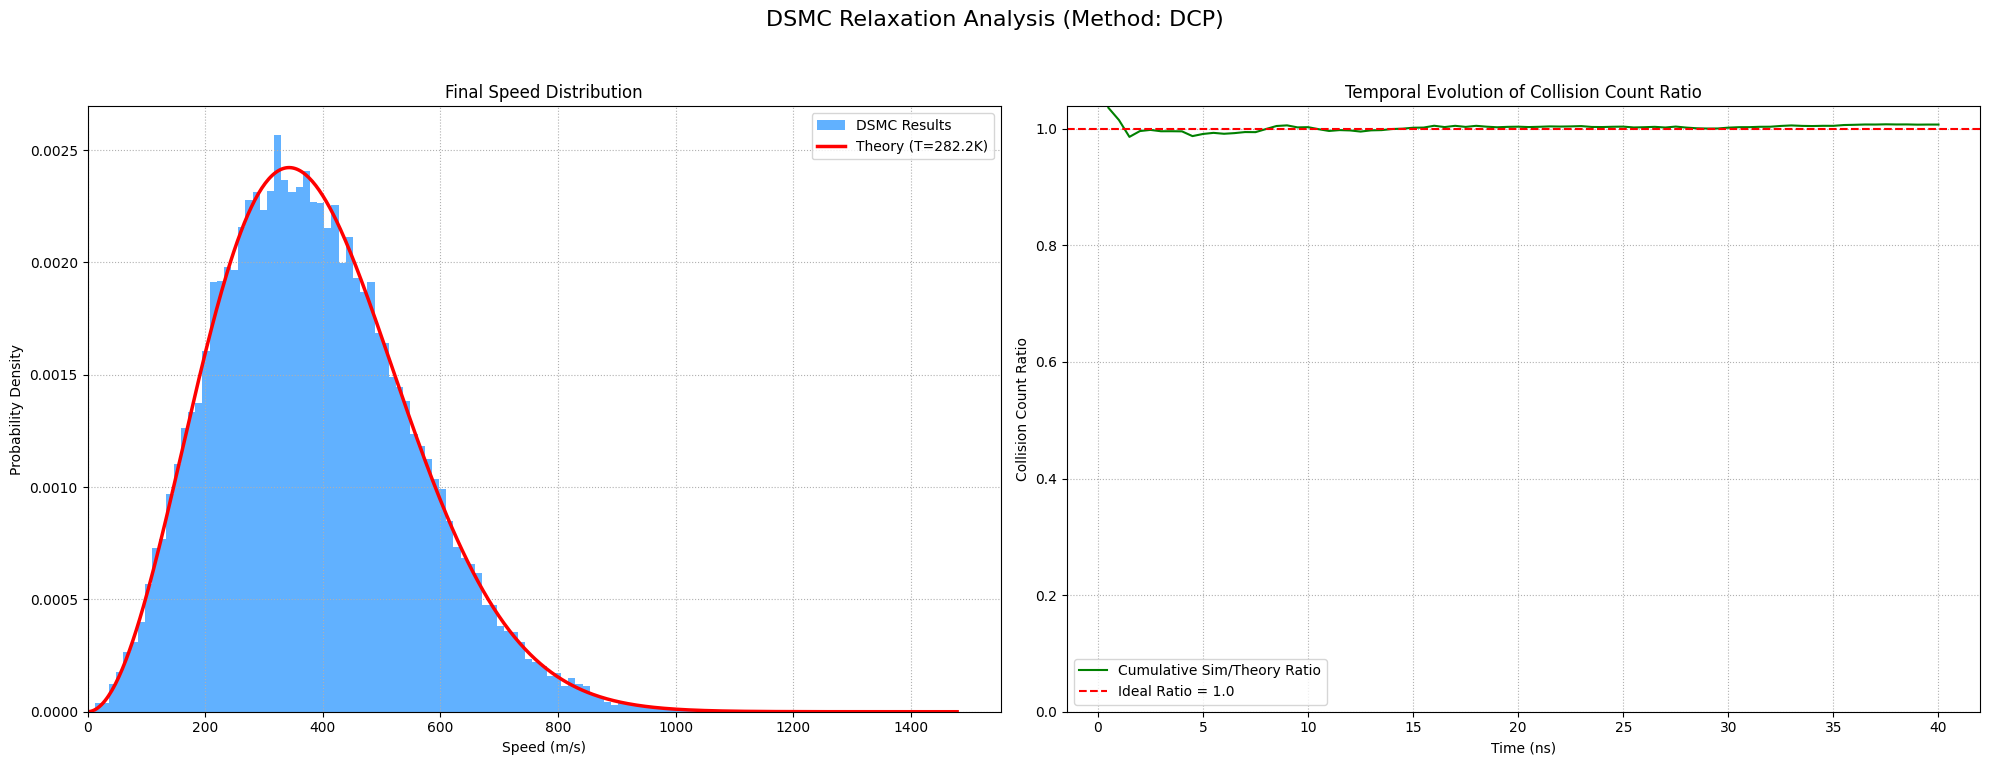

In [3]:
# -*- coding: utf-8 -*-
# --- DSMC Relaxation - V4.7 - FINAL CORRECTED AND COMPLETE CODE ---
# This version provides a complete, runnable script with a choice between three
# collision schemes and fixes the NameError by defining functions in the correct order.

import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit
import time

# --- Constants and Physical Parameters ---
MASS_AR = 39.948e-3 / 6.022e23
KB = 1.380649e-23
D_REF_AR = 4.17e-10
T_REF_AR = 273.0
OMEGA_VHS = 0.50
PI = 3.141592654

# --- Simulation Parameters ---
LX = 1.0e-6
RHO_INIT = 1.78
T_INIT = 273.0
NUM_CELLS_X = 100
PARTICLES_PER_CELL_INIT = 5
TOTAL_PARTICLES_SIM = NUM_CELLS_X * PARTICLES_PER_CELL_INIT
N_DENSITY_REAL = RHO_INIT / MASS_AR
# This conceptual volume is used to correctly calculate FNUM
CELL_VOLUME_CONCEPTUAL = (LX) / NUM_CELLS_X
FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
DT = 1.0e-12
TOTAL_TIME = 4.0e-8
SAMPLING_START_TIME = 1.0e-8
SAMPLING_INTERVAL = 500

# --- Numba-Jitted Core Functions ---

@njit(nopython=True)
def gamma_function_approx(x):
    a = 1.0
    y = x
    if y < 1.0: a = a / y
    else:
        while y >= 1.0:
            y = y - 1.0
            a = a * (y + 1.0)
    gamma_val = a * (1.0 - 0.5748646*y + 0.9512363*y**2 - 0.6998588*y**3 + 0.4245549*y**4 - 0.1010678*y**5)
    return gamma_val

@njit(nopython=True)
def calculate_vhs_sigma_g(vr_mag):
    if vr_mag < 1e-9: return 0.0
    exponent = OMEGA_VHS - 0.5
    c_ref_sq = 2 * KB * T_REF_AR / MASS_AR
    gamma_val = gamma_function_approx(2.5 - OMEGA_VHS)
    sigma_g = (PI * D_REF_AR**2) * vr_mag * ((c_ref_sq / vr_mag**2)**exponent) / gamma_val
    return sigma_g

@njit(nopython=True)
def perform_post_collision(p1_idx, p2_idx, particles, rng_state):
    vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
    vr_mag = np.sqrt(np.sum(vr**2))
    if vr_mag < 1e-9: return False
    vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
    cos_chi = 2 * rng_state.random() - 1.0
    sin_chi = np.sqrt(1.0 - cos_chi**2)
    phi_chi = 2.0 * PI * rng_state.random()
    rand_vec = np.array([sin_chi * np.cos(phi_chi), sin_chi * np.sin(phi_chi), cos_chi])
    vr_prime = vr_mag * rand_vec
    particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
    particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime
    return True

@njit(nopython=True)
def perform_collisions(method, particles, indices_in_cell, cell_vol, dt, fnum, rng_state, sigma_g_max_cell):
    n_accepted = 0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2: return 0, sigma_g_max_cell

    if method == 1: # SBT
        prob_const = fnum * dt / cell_vol
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
                vr_mag = np.sqrt(np.sum(vr**2))
                if vr_mag < 1e-9: continue
                sigma_g = calculate_vhs_sigma_g(vr_mag)
                collision_prob = prob_const * sigma_g
                if rng_state.random() < collision_prob:
                    if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                        n_accepted += 1
        return n_accepted, sigma_g_max_cell
    elif method == 2: # DCP
        num_pairs = num_particles_in_cell * (num_particles_in_cell - 1) // 2
        pairs = np.empty((num_pairs, 2), dtype=np.int32)
        weights = np.empty(num_pairs, dtype=np.float64)
        pair_count = 0
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                distance = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                weights[pair_count] = 1.0 / (distance + 1e-10)
                pairs[pair_count, 0] = p1_idx
                pairs[pair_count, 1] = p2_idx
                pair_count += 1
        sum_of_sigma_g = 0.0
        for i in range(num_pairs):
            p1_idx, p2_idx = pairs[i]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sum_of_sigma_g += calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
        expected_collisions = (sum_of_sigma_g * fnum * dt) / cell_vol
        num_collisions_to_perform = int(np.floor(expected_collisions + rng_state.random()))
        for _ in range(num_collisions_to_perform):
            if np.sum(weights) < 1e-12: break
            selected_idx = np.argmax(weights)
            p1_idx, p2_idx = pairs[selected_idx]
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
            weights[selected_idx] = 0.0
        return n_accepted, sigma_g_max_cell
    elif method == 3: # NTC
        num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
        if sigma_g_max_cell < 1e-20: sigma_g_max_cell = 1e-18
        num_pairs_to_select = int(num_pairs_float * fnum * sigma_g_max_cell * dt / cell_vol + rng_state.random())
        for _ in range(num_pairs_to_select):
            p1_idx_local = rng_state.integers(0, num_particles_in_cell)
            p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            while p1_idx_local == p2_idx_local: p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            p1_idx, p2_idx = indices_in_cell[p1_idx_local], indices_in_cell[p2_idx_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
            if sigma_g_current > sigma_g_max_cell: sigma_g_max_cell = sigma_g_current
            if sigma_g_max_cell > 1e-20 and rng_state.random() < sigma_g_current / sigma_g_max_cell:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
        return n_accepted, sigma_g_max_cell
    return 0, sigma_g_max_cell

@njit(nopython=True)
def calculate_total_theoretical_collisions(TOTAL_TIME, avg_temp, total_volume):
    spm1 = PI * D_REF_AR**2
    temp_factor = (avg_temp / T_REF_AR)**(1.0 - OMEGA_VHS)
    velocity_factor = np.sqrt(KB * T_REF_AR / (PI * MASS_AR))
    tcol = (1.0 * TOTAL_TIME * N_DENSITY_REAL**2 * total_volume * spm1 * temp_factor * velocity_factor) / FNUM
    return tcol

# --- Plotting and Initialization functions defined BEFORE run_dsmc_simulation ---

def plot_results(sampled_speeds, final_temp, method_name, time_history, ratio_history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f'DSMC Relaxation Analysis (Method: {method_name})', fontsize=16)

    ax1.hist(sampled_speeds, bins=100, density=True, label=f'DSMC Results', alpha=0.7, color='dodgerblue')
    if len(sampled_speeds) > 0: v_max_range = np.max(sampled_speeds) * 1.2
    else: v_max_range = 1500
    v_theory = np.linspace(0, v_max_range, 500)
    pv_theory = ((MASS_AR / (2 * PI * KB * final_temp))**1.5 * 4 * PI * v_theory**2 * np.exp(-MASS_AR * v_theory**2 / (2 * KB * final_temp)))
    ax1.plot(v_theory, pv_theory, 'r-', linewidth=2.5, label=f'Theory (T={final_temp:.1f}K)')
    ax1.set_xlabel('Speed (m/s)'); ax1.set_ylabel('Probability Density'); ax1.set_title('Final Speed Distribution')
    ax1.legend(); ax1.grid(True, linestyle=':'); ax1.set_xlim(left=0)

    ax2.plot(np.array(time_history) * 1e9, ratio_history, 'g-', label='Cumulative Sim/Theory Ratio')
    ax2.axhline(1.0, color='r', linestyle='--', label='Ideal Ratio = 1.0')
    ax2.set_xlabel('Time (ns)'); ax2.set_ylabel('Collision Count Ratio'); ax2.set_title('Temporal Evolution of Collision Count Ratio')
    ax2.legend(); ax2.grid(True, linestyle=':'); ax2.set_ylim(bottom=0)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

def initialize_particles(rng_state):
    particles = np.zeros((TOTAL_PARTICLES_SIM, 4))
    print("Initializing particles with Maxwell-Boltzmann velocity distribution...")
    particles[:, 0] = rng_state.random(TOTAL_PARTICLES_SIM) * LX

    v_thermal_std = np.sqrt(KB * T_INIT / MASS_AR)
    particles[:, 1:4] = rng_state.normal(0, v_thermal_std, (TOTAL_PARTICLES_SIM, 3))
    particles[:, 1:4] -= np.mean(particles[:, 1:4], axis=0)

    print(f"Initialized {TOTAL_PARTICLES_SIM} particles.")
    return particles

def run_dsmc_simulation(method_code):
    method_map = {1: 'SBT', 2: 'DCP', 3: 'NTC'}
    collision_method_name = method_map[method_code]
    print(f"--- DSMC Relaxation using method: {collision_method_name} ---")

    rng_state = np.random.default_rng(seed=42)
    particles = initialize_particles(rng_state)

    sampled_speeds = []
    time_history, ratio_history = [], []
    sigma_g_max = np.full(NUM_CELLS_X, 1e-18)

    total_simulated_collisions = 0

    start_time = time.time()
    num_steps = int(TOTAL_TIME / DT)
    sampling_start_step = int(SAMPLING_START_TIME / DT)
    cell_width = LX / NUM_CELLS_X

    # <<< CORRECTED: Total volume definition to be consistent >>>
    total_volume = LX

    for step in range(1, num_steps + 1):
        particles[:, 0] += particles[:, 1] * DT
        particles[:, 0] %= LX
        cell_indices = (particles[:, 0] / cell_width).astype(np.int64)

        accepted_this_step = 0
        for i in range(NUM_CELLS_X):
            indices_in_cell_i = np.where(cell_indices == i)[0]
            n_accepted, new_sigma_g_max = perform_collisions(method_code, particles, indices_in_cell_i, CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state, sigma_g_max[i])
            sigma_g_max[i] = new_sigma_g_max
            accepted_this_step += n_accepted

        total_simulated_collisions += accepted_this_step

        if step % SAMPLING_INTERVAL == 0 and step > 1:
            current_time = step * DT
            current_temp = (1.0 / (3.0 * KB)) * MASS_AR * np.mean(np.var(particles[:, 1:4], axis=0)) * 3.0

            if current_temp > 10.0:
                total_theoretical_collisions = calculate_total_theoretical_collisions(current_time, current_temp, total_volume)
                if total_theoretical_collisions > 0:
                    ratio = total_simulated_collisions / total_theoretical_collisions
                    time_history.append(current_time)
                    ratio_history.append(ratio)

        if step >= sampling_start_step and step % 200 == 0:
            sampled_speeds.extend(np.sqrt(np.sum(particles[:, 1:4]**2, axis=1)))

        if step % (num_steps // 10) == 0:
            print(f"Step: {step}/{num_steps} | Total Collisions: {total_simulated_collisions}")

    end_time = time.time()
    final_temp = (1.0 / (3.0 * KB)) * MASS_AR * np.mean(np.sum(np.var(particles[:, 1:4], axis=0)))
    print(f"\nSimulation finished in {end_time - start_time:.2f} seconds.")
    print(f"Final Equilibrium Temperature: {final_temp:.2f} K")
    print(f"Total Simulated Collisions: {total_simulated_collisions}")

    total_theoretical_collisions_final = calculate_total_theoretical_collisions(TOTAL_TIME, final_temp, total_volume)
    print(f"Total Theoretical Collisions (TCOL): {total_theoretical_collisions_final:.2f}")

    if total_theoretical_collisions_final > 0:
        final_ratio = total_simulated_collisions / total_theoretical_collisions_final
        print(f"FINAL RATIO (Simulated/Theoretical): {final_ratio:.4f}")

    if sampled_speeds:
        plot_results(np.array(sampled_speeds), final_temp, collision_method_name, time_history, ratio_history)

if __name__ == "__main__":
    while True:
        choice = input("Choose method: [1] SBT, [2] DCP, [3] NTC: ")
        if choice in ['1', '2', '3']:
            run_dsmc_simulation(method_code=int(choice))
            break
        else:
            print("Invalid input.")